In [ ]:

!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

^C


In [ ]:
import torch
print(f"설치된 버전: {torch.__version__}")
print(f"GPU 가능 여부: {torch.cuda.is_available()}")

설치된 버전: 2.5.1+cu121
GPU 가능 여부: True


In [ ]:
import os
import random
import shutil

# 경로 설정
base_path = 'C:/Users/SSAFY/Desktop/SafeDeck_Data' 
img_train_dir = os.path.join(base_path, 'images/train')
lbl_train_dir = os.path.join(base_path, 'labels/train')

img_val_dir = os.path.join(base_path, 'images/val')
lbl_val_dir = os.path.join(base_path, 'labels/val')

# val 폴더 만들기 
os.makedirs(img_val_dir, exist_ok=True)
os.makedirs(lbl_val_dir, exist_ok=True)

# 파일 목록 가져오기
images = [f for f in os.listdir(img_train_dir) if f.endswith('.JPG') or f.endswith('.jpg')]
random.seed(42) # 언제 실행해도 똑같이 나뉘도록 시드 고정
random.shuffle(images)

# # 20% 만큼 나누기
# val_size = int(len(images) * 0.2)
# val_images = images[:val_size]

# for img_name in val_images:
#     # 이미지 이동
#     shutil.move(os.path.join(img_train_dir, img_name), os.path.join(img_val_dir, img_name))
    
#     # JSON 이동 
#     json_name = img_name.rsplit('.', 1)[0] + '.json'
#     if os.path.exists(os.path.join(lbl_train_dir, json_name)):
#         shutil.move(os.path.join(lbl_train_dir, json_name), os.path.join(lbl_val_dir, json_name))

# print(f" 이미지 {len(val_images)}장 val 폴더로 옮김")

In [ ]:
import json
import os


# 선박 결함 번호표 & 영어 이름 매치시킴
ship_map = {
    101: 0, 201: 1, 202: 2, 203: 3, 204: 4, 
    205: 5, 206: 6, 207: 7, 301: 8, 302: 9, 303: 10
}

def json_to_txt(target_split):
    label_path = os.path.join(base_path, 'labels', target_split)
    json_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    
    for j_file in json_files:
        with open(os.path.join(label_path, j_file), 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        img_w = data['images'][0]['width']
        img_h = data['images'][0]['height']
        
        # .txt 파일 만들기
        with open(os.path.join(label_path, j_file.replace('.json', '.txt')), 'w') as f_out:
            for ann in data['annotations']:
                cat_id = ann['category_id']
                if cat_id in ship_map:
                    class_idx = ship_map[cat_id]
                    
                    #  bbox가 있는지 먼저 확인
                    # .get('bbox')를 쓰면 박스가 없어도 에러가 나지 않고 None 리턴함.
                    bbox = ann.get('bbox')
                    
                    if bbox: # 박스 정보가 있을 때만 실행
                        x, y, w, h = bbox
                        
                       
                        x_c = (x + w/2) / img_w
                        y_c = (y + h/2) / img_h
                        wn = w / img_w
                        hn = h / img_h
                        
                        f_out.write(f"{class_idx} {x_c:.6f} {y_c:.6f} {wn:.6f} {hn:.6f}\n")
                    else:
                        # 101(정상)처럼 박스가 없는 경우는 그냥 넘어감
                        # => YOLO는 내용이 없는 .txt 파일을 정상 이미지로 인식함 !! 트러블 슈팅 기록하기
                        continue

json_to_txt('train')
json_to_txt('val')
print(" 변환 완료 ")

✅ 이제 에러 없이 변환 완료! 요약 노트가 잘 만들어졌을 거예요.


In [ ]:
from ultralytics import YOLO

# 1. 사전 학습된 모델(Pre-trained Model) 불러오기

model = YOLO('yolov8n.pt') 

# 2. 학습(Training) 시작
model.train(
    data='ship_data.yaml',   #  지도 파일 경로
    epochs=10,              # 전체 데이터 10번 반복 공부
    imgsz=640,               # 이미지 크기 640x640으로 맞춰서 공부
    batch=16,                # 한 번에 16장씩 묶어서 학습 
    name='SafeDeck_Ship_V1', # 결과 저장 폴더 이름
    device='cuda'               # GPU가 있다면 cuda로 , 없으면 cpu로 설정
)

New https://pypi.org/project/ultralytics/8.4.0 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.253  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ship_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=SafeDeck_Ship_V110, nbs=64, nms=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 2,  3,  4,  5,  6,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002283AF7B130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046, 


image 1/1 C:\Users\SSAFY\Desktop\SafeDeck_Data\images\val\test_image.jpg: 640x480 1 Crack, 76.7ms
Speed: 7.0ms preprocess, 76.7ms inference, 18.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\SSAFY\Desktop\SafeDeck_Data\runs\detect\predict9


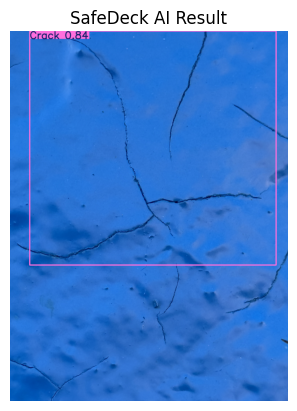

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt



img_path = r'C:\Users\SSAFY\Desktop\SafeDeck_Data\images\val\test_image.jpg' #

# 모델 불러오기
model = YOLO(r'C:\Users\SSAFY\Desktop\SafeDeck_Data\runs\detect\SafeDeck_Ship_V110\weights\best.pt') #

# 예측 실행
results = model.predict(source=img_path, save=True, conf=0.25, device=0)[0] #

# 결과 확인
anno_img = results.plot()
plt.imshow(cv2.cvtColor(anno_img, cv2.COLOR_BGR2RGB))
plt.title("SafeDeck AI Result") #
plt.axis('off')
plt.show()